# SEA single-drift experiment — STUDD

STUDD (Student-Teacher Unsupervised Drift Detection) applied to the SEA benchmark.

**Teacher**: `DNNClassifier` trained offline on reference data (SEA concept f=4, θ=9.5).  
**Student**: `HoeffdingTree` (capymoa MOA classifier) that learns to mimic teacher predictions.  
**Drift signal**: ADWIN applied to the binary student–teacher agreement at each step.  
**Stream**: capymoa `DriftStream` with an abrupt SEA f=4 → f=3 (θ=9.5 → θ=7.0) switch at index 5 000.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from capymoa.stream.generator import SEA as CapySEA
from capymoa.stream.drift import DriftStream, Drift
from capymoa.classifier import HoeffdingTree
from capymoa.drift.detectors import STUDD, ADWIN

from tscls.models.dnn_classifier import DNNClassifier
from tscls.training.base_trainer import BaseTrainer

from helpers import (
    configure_matplotlib,
    rolling_mean,
    add_drift_markers,
    plot_sea_data,
    collect_capymoa_samples,
)

configure_matplotlib()

## Parameters

In [2]:
n1        = 5_000   # reference samples
n2        = 10_000  # stream samples
drift_pos = 5_000   # abrupt drift position in stream
seed      = 1

# capymoa SEA function IDs (1-indexed, MOA convention)
# and their decision thresholds θ (x0 + x1 vs θ)
CAPYMOA_SEA_THRESHOLDS = {1: 8.0, 2: 9.0, 3: 7.0, 4: 9.5}
f_old_moa = 4   # θ=9.5  (matches custom f=3 used in test_sea.ipynb)
f_new_moa = 3   # θ=7.0  (matches custom f=2)
theta_old = CAPYMOA_SEA_THRESHOLDS[f_old_moa]
theta_new = CAPYMOA_SEA_THRESHOLDS[f_new_moa]

device = "cuda" if torch.cuda.is_available() else "cpu"

## Data generation

In [3]:
# Reference data
sea_ref = CapySEA(
    function=f_old_moa,
    instance_random_seed=seed,
    noise_percentage=0,
    balance_classes=True,
)
X_ref, y_ref = collect_capymoa_samples(sea_ref, n1)

# Stream — pre-collect for visualisation, then restart
drift_stream = DriftStream(stream=[
    CapySEA(function=f_old_moa, instance_random_seed=seed + 10, noise_percentage=0),
    Drift(position=drift_pos, width=0),
    CapySEA(function=f_new_moa, instance_random_seed=seed + 20, noise_percentage=0),
])
X_stream, y_stream = collect_capymoa_samples(drift_stream, n2)
drift_stream.restart()

print(f"Reference : {X_ref.shape}  classes={np.unique(y_ref,    return_counts=True)[1]}")
print(f"Stream    : {X_stream.shape}  classes={np.unique(y_stream, return_counts=True)[1]}")

Reference : (5000, 3)  classes=[2500 2500]
Stream    : (10000, 3)  classes=[3563 6437]


## Reference and stream data

The SEA decision boundary depends on $x_0 + x_1 \leq \theta$.
Plotting that sum makes the concept shift visible.

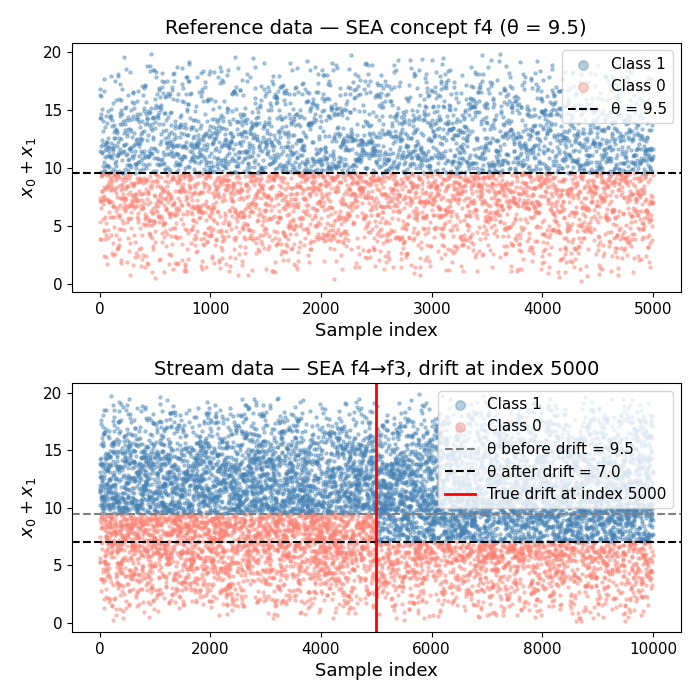

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7))
plot_sea_data(
    axes,
    X_ref, y_ref,
    X_stream, y_stream,
    theta_old, theta_new,
    f_old_moa, f_new_moa,
    drift_pos,
)
plt.tight_layout()
plt.show()

## Teacher — offline training

Train a `DNNClassifier` (Model 1) on the reference data.
This model serves as the static teacher for STUDD.

In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_ref)
x_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y_ref,    dtype=torch.float32)

teacher   = DNNClassifier(layer_sizes=[3, 256, 128, 64, 1])
trainer   = BaseTrainer(loss_function=nn.BCEWithLogitsLoss(), gamma1=0.9, s1=20)
optimizer = torch.optim.SGD(teacher.parameters(), lr=1e-2)

print(f"Training on: {device}")
train_losses = trainer.train_model(
    model=teacher,
    x_reference=x_t,
    y_reference=y_t,
    optimizer=optimizer,
    epochs=1000,
    batch_size=256,
)
print("Offline training complete.")

Training on: cuda
Offline training complete.


## Training loss curve

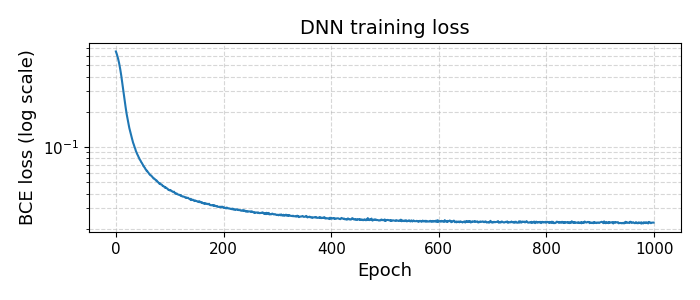

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))

ax.plot(train_losses)
ax.set_yscale("log")
ax.set_title("DNN training loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss (log scale)")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## STUDD detector

- **Student**: `HoeffdingTree` (online decision tree, learns teacher predictions).
- **Base detector**: `ADWIN` (monitors student–teacher agreement).
- **`min_n_instances`**: 500 — drift monitoring starts only after the student has seen enough samples.

In [7]:
student = HoeffdingTree(schema=drift_stream.get_schema())
studd   = STUDD(student=student, min_n_instances=2000, detector=ADWIN())

## Online stream monitoring

In [8]:
studd_drift_points: list[int] = []
teacher_preds: list[int]  = []
true_labels:   list[int]  = []
i = 0

teacher.to(device)
teacher.eval()

while drift_stream.has_more_instances() and i < n2:
    instance = drift_stream.next_instance()

    x_sc = scaler.transform(instance.x.reshape(1, -1)).astype(np.float32)
    x_t  = torch.tensor(x_sc).to(device)
    with torch.no_grad():
        teacher_pred = int(torch.round(torch.sigmoid(teacher(x_t))).item())

    studd.add_element(instance, teacher_pred)

    teacher_preds.append(teacher_pred)
    true_labels.append(instance.y_index)

    if studd.detected_change():
        studd_drift_points.append(i)

    i += 1

teacher_preds = np.array(teacher_preds)
true_labels   = np.array(true_labels)

print(f"Total STUDD detections : {len(studd_drift_points)}")
print(f"First 20               : {studd_drift_points[:20]}")
if studd_drift_points:
    delay = studd_drift_points[0] - drift_pos
    print(f"First detected at {studd_drift_points[0]}  (delay = {delay:+d})")
else:
    print("No drift detected.")

Total STUDD detections : 5
First 20               : [4622, 4686, 5262, 5966, 6286]
First detected at 4622  (delay = -378)


## Detection results

Student–teacher agreement over the stream, the rolling agreement signal,
and the rolling teacher classification accuracy.

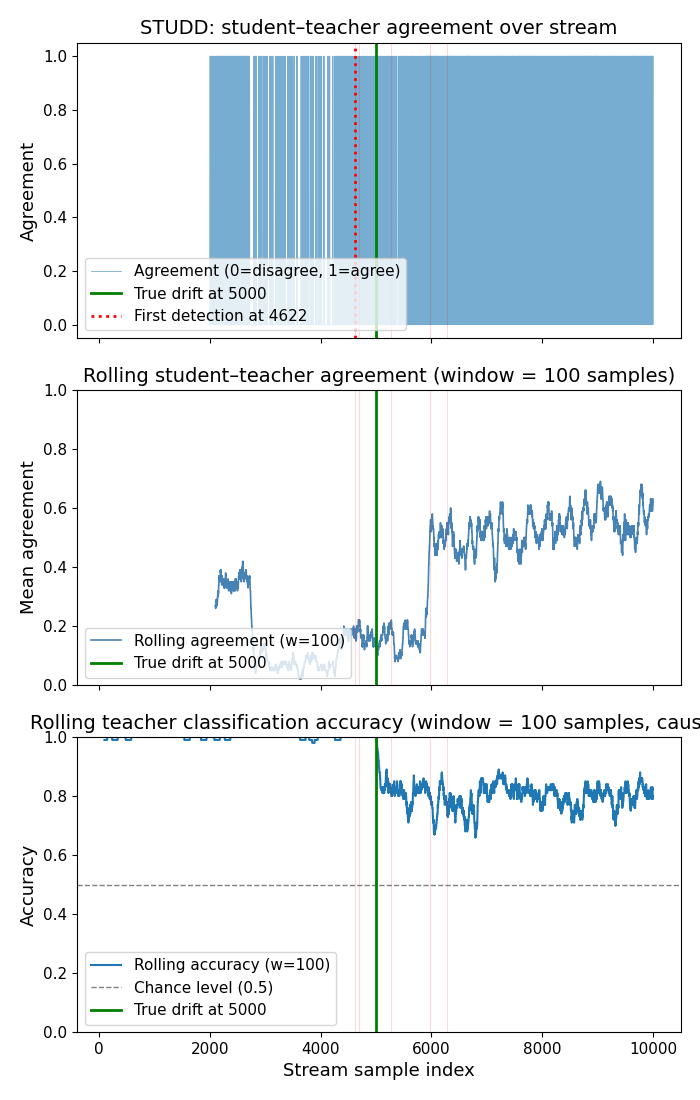

In [9]:
agreement  = np.array(studd.data)   # 0/1 per step, starts at min_n_instances
stream_idx = np.arange(n2)
offset     = studd.min_n_instances  # agreement x-axis starts here

window     = 100
is_correct = (teacher_preds == true_labels).astype(float)
rolling_acc, rolling_idx = rolling_mean(is_correct, window)

rolling_agr, rolling_agr_idx_rel = rolling_mean(agreement, window)
rolling_agr_idx = rolling_agr_idx_rel + offset

n_before = sum(d < drift_pos for d in studd_drift_points)

fig, axes = plt.subplots(3, 1, figsize=(7, 11), sharex=True)

# --- Student–teacher agreement (raw) ---
ax = axes[0]
ax.plot(
    np.arange(len(agreement)) + offset,
    agreement,
    linewidth=0.6,
    alpha=0.6,
    label="Agreement (0=disagree, 1=agree)",
)
add_drift_markers(
    ax,
    drift_pos,
    studd_drift_points,
    first_label=f"First detection at {studd_drift_points[0]}",
)
ax.set_title("STUDD: student–teacher agreement over stream")
ax.set_ylabel("Agreement")
ax.legend(loc="lower left")

# --- Rolling agreement ---
ax = axes[1]
ax.plot(
    rolling_agr_idx,
    rolling_agr,
    linewidth=1.2,
    color="steelblue",
    label=f"Rolling agreement (w={window})",
)
add_drift_markers(ax, drift_pos, studd_drift_points)
ax.set_ylim(0, 1)
ax.set_title(f"Rolling student–teacher agreement (window = {window} samples)")
ax.set_ylabel("Mean agreement")
ax.legend(loc="lower left")

# --- Rolling teacher classification accuracy ---
ax = axes[2]
ax.plot(
    rolling_idx,
    rolling_acc,
    linewidth=1.5,
    label=f"Rolling accuracy (w={window})",
)
ax.axhline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label="Chance level (0.5)",
)
add_drift_markers(ax, drift_pos, studd_drift_points)
ax.set_ylim(0, 1)
ax.set_title(
    f"Rolling teacher classification accuracy (window = {window} samples, causal)"
)
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

## Debug: reference vs stream teacher accuracy

Re-compute teacher accuracy on the reference data and compare with stream accuracy.
This shows whether the teacher's performance degrades after drift.

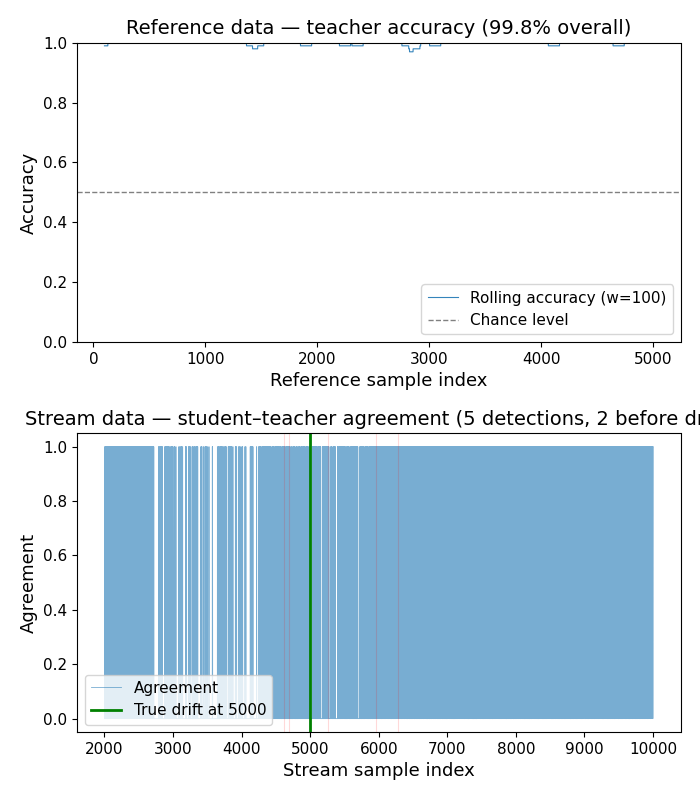

Teacher accuracy on reference : 99.8%
Teacher accuracy on stream    : before drift 99.8%  / after drift 79.9%


In [10]:
teacher.to(device)
teacher.eval()

x_ref_scaled = scaler.transform(X_ref.astype(np.float32))
x_ref_t      = torch.tensor(x_ref_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    ref_preds = torch.round(torch.sigmoid(teacher(x_ref_t))).cpu().numpy().flatten()

is_correct_ref = (ref_preds == y_ref).astype(float)
rolling_acc_ref, rolling_idx_ref = rolling_mean(is_correct_ref, window)

n_fp = sum(d < drift_pos for d in studd_drift_points)

fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# --- Reference data teacher accuracy ---
ax = axes[0]
acc_ref = float(is_correct_ref.mean())
ax.plot(
    rolling_idx_ref,
    rolling_acc_ref,
    linewidth=0.8,
    alpha=0.9,
    label=f"Rolling accuracy (w={window})",
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, label="Chance level")
ax.set_ylim(0, 1)
ax.set_title(
    f"Reference data — teacher accuracy ({100 * acc_ref:.1f}% overall)"
)
ax.set_xlabel("Reference sample index")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower right")

# --- Stream data student–teacher agreement ---
ax = axes[1]
ax.plot(
    np.arange(len(agreement)) + offset,
    agreement,
    linewidth=0.6,
    alpha=0.6,
    label="Agreement",
)
add_drift_markers(ax, drift_pos, studd_drift_points)
ax.set_title(
    f"Stream data — student–teacher agreement"
    f" ({len(studd_drift_points)} detections, {n_fp} before drift)"
)
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Agreement")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

print(f"Teacher accuracy on reference : {100 * acc_ref:.1f}%")
print(
    f"Teacher accuracy on stream    : "
    f"before drift {100 * is_correct[:drift_pos].mean():.1f}%  "
    f"/ after drift {100 * is_correct[drift_pos:].mean():.1f}%"
)

## Agreement distributions

Overlaid histograms of student–teacher agreement **before** the true drift
(stream indices `< drift_pos`) and **after** (`≥ drift_pos`).

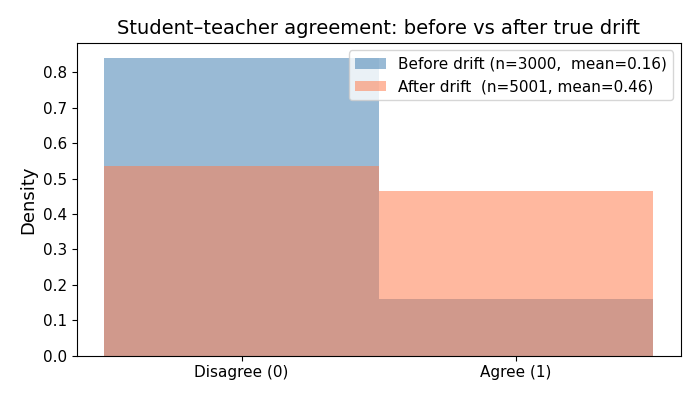

In [11]:
# agreement starts at index offset; map to stream indices
agr_stream_idx = np.arange(len(agreement)) + offset
pre_agr  = agreement[agr_stream_idx <  drift_pos]
post_agr = agreement[agr_stream_idx >= drift_pos]

mean_pre  = pre_agr.mean()  if len(pre_agr)  > 0 else float("nan")
mean_post = post_agr.mean() if len(post_agr) > 0 else float("nan")

fig, ax = plt.subplots(figsize=(7, 4))
bins = [-0.5, 0.5, 1.5]
ax.hist(
    pre_agr,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"Before drift (n={len(pre_agr)},  mean={mean_pre:.2f})",
    color="steelblue",
)
ax.hist(
    post_agr,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"After drift  (n={len(post_agr)}, mean={mean_post:.2f})",
    color="coral",
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Disagree (0)", "Agree (1)"])
ax.set_ylabel("Density")
ax.set_title("Student–teacher agreement: before vs after true drift")
ax.legend(loc="best")
plt.tight_layout()
plt.show()